# Lista 3 - Séries Temporais

Componentes do Grupo:

Letícia Yumi Ichibara - 834396

Marcelo Xinhong Huang - 832111

Pedro Henrique de Araújo - 831235

---

### Enunciado:

*Ajustar um modelo para duas séries.*

*Se quiserem tentem ajustar modelo para alguma série de https://finance.yahoo.com/*

*fiquem à vontade.*

---

# 📈 Análise de Séries Temporais em R

Este notebook apresenta o **procedimento** para análise de séries temporais, seguindo a metodologia:

1. Carregamento e visualização dos dados
2. Decomposição da série
3. Teste de estacionariedade
4. Transformações (se necessário)
5. Identificação do modelo (ACF / PACF)
6. Ajuste do modelo ARIMA
7. Diagnóstico dos resíduos
8. Previsão


---


In [7]:
library(forecast)
library(tseries)
library(ggplot2)
library(zoo)
library(quantmod)
library(astsa)

---

### Série 1

Usaremos a série `unemp` — taxa de desemprego (unemployment rate) dos Estados Unidos de 1890 a 1988.

---
## 1. Carregamento e visualização inicial

O primeiro passo é **olhar pros dados**. Queremos entender:
- Existe **tendência** (crescimento ou queda ao longo do tempo)?
- Existe **sazonalidade** (padrões que se repetem periodicamente)?
- Tem anormalidade?
- A variância é **constante** ou cresce com o tempo?



```
Início: 1890 1 
Fim: 1988 1 
Frequência: 1 observações/ano
Comprimento: 99 observações

Resumo estatístico:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1823  1.3736  1.7047  1.7514  2.0540  3.2149 

```

![serie original](1_Serie_original.png)
![serie original com médias moveis](1_Serie_e_ma.png)


In [8]:
# 1. Pegar os dados NelPlo do pacote tseries
data(NelPlo)

# 2. Extrair a série unemp como ts
ts_data <- NelPlo[, "unemp"]

# 3. Tirar NAs que estão no começo da série pois a série de interesse começa a ser registrada depois
dados_sem_na <- na.omit(as.numeric(ts_data))
novo_start <- start(ts_data) + c(0, (min(which(!is.na(ts_data)))-1) / frequency(ts_data))
ts_limpa <- ts(dados_sem_na, start = novo_start, frequency= frequency(ts_data))

# 4. objeto ts que vamos usar
ts_data <- ts_limpa

# Informações básicas
cat("Classe:", class(ts_data), "\n")
cat("Início:", start(ts_data), "\n")
cat("Fim:", end(ts_data), "\n")
cat("Frequência:", frequency(ts_data), "observações/ano\n")
cat("Comprimento:", length(ts_data), "observações\n")
cat("\nResumo estatístico:\n")
print(summary(ts_data))

Classe: ts 
Início: 1890 1 
Fim: 1988 1 
Frequência: 1 observações/ano
Comprimento: 99 observações

Resumo estatístico:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1823  1.3736  1.7047  1.7514  2.0540  3.2149 


Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."


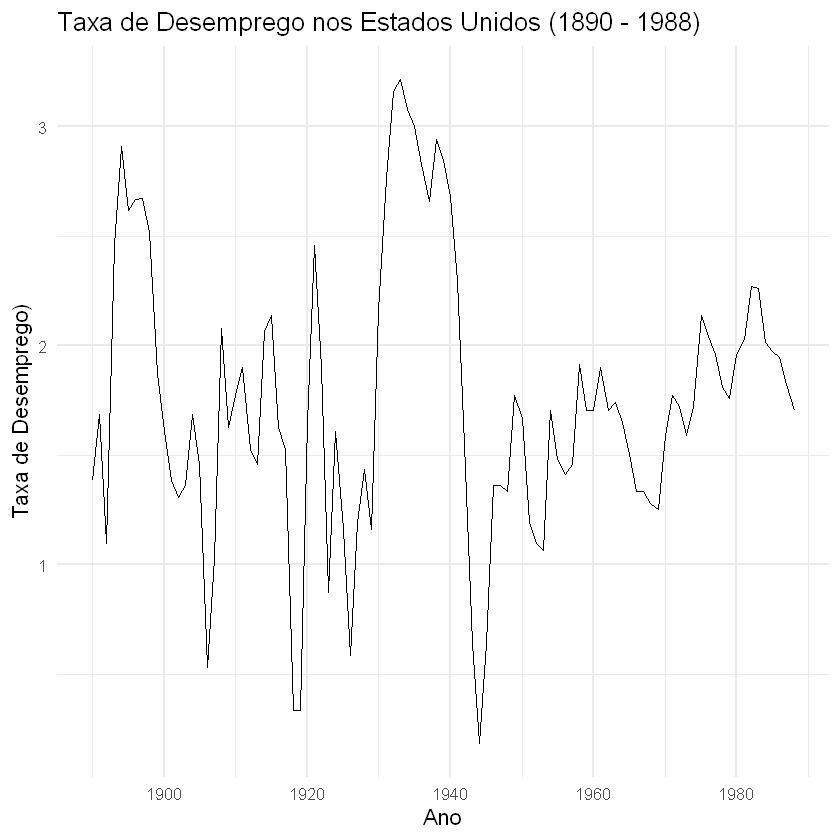

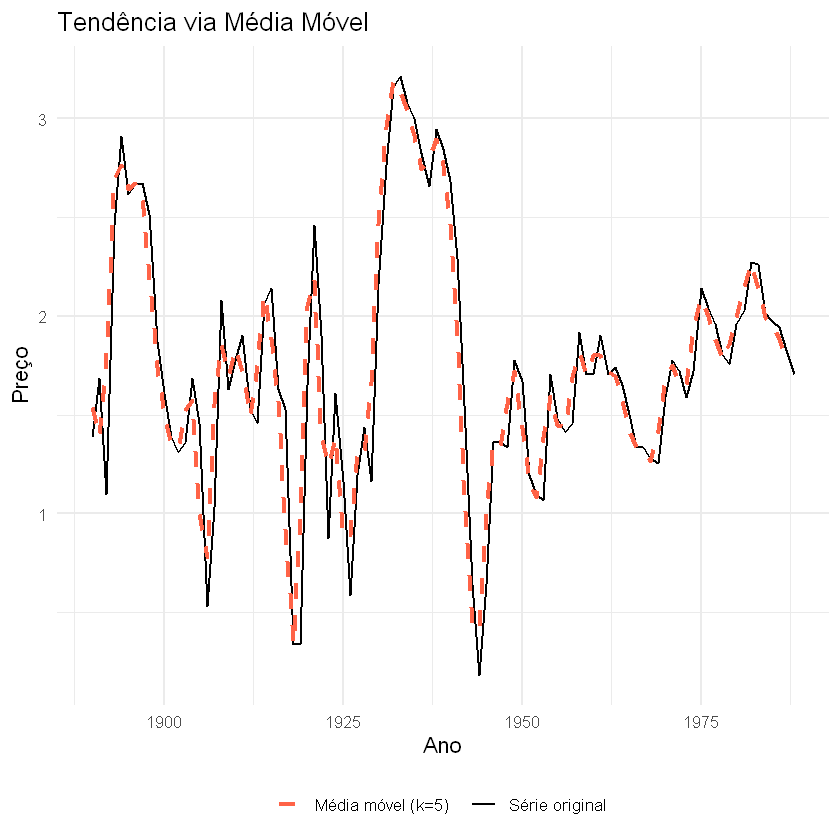

In [9]:
# Visualização da série original
autoplot(ts_data) +
  labs(
    title = "Taxa de Desemprego nos Estados Unidos (1890 - 1988)",
    x = "Ano",
    y = "Taxa de Desemprego)"
  ) +
  theme_minimal(base_size = 13)

# Visualização de média móvel
tendencia <- rollmean(ts_data, k = 2, fill = NA)

df_plot <- data.frame(
  ano       = as.numeric(time(ts_data)),
  original  = as.numeric(ts_data),
  tendencia = as.numeric(tendencia)
)

ggplot(df_plot, aes(x = ano)) +
  geom_line(aes(y = original,  color = "Série original"), linewidth = 0.8) +
  geom_line(aes(y = tendencia, color = "Média móvel (k=5)"), linewidth = 1.2, linetype = "dashed") +
  scale_color_manual(values = c("Série original" = "black", "Média móvel (k=5)" = "tomato")) +
  labs(title = "Tendência via Média Móvel", x = "Ano", y = "Preço", color = NULL) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "bottom")

**Observações da visualização:**

- Não há uma tendência decrescente clara ao longo de todo o período. A série oscila bastante e apresenta diferentes fases de crescimento e queda
- Existem períodis de forte variação, uns picos mais acentuados entre 1930 e 1940, e umas quedas(vales) em torno de 1915-1920 e 1940-1945
- A homocedasticidade não é muito evidente já que a amplitude das oscilações parece variar ao longo do tempo, especialmente entre as décadas 1920 e 1940 que aparenta ter uma variação maior.
- A série parace ter um comportamento periódico que pode indicar a presença de sazonalidade, embora não é muito identificável (o que também é esperado para os dados anuais).
- O gráfcico de média móvel mostra as mesmas característica descritas acima.

---
## 2. Decomposição da série

Não vamos decompor a série pois a frequência de dados é 1 (são dados anuais), ou seja não tem sazonalidade.

---
## 3. Teste de Estacionariedade

Queremos ajustar um modelo ARIMA para os dados. (Não é SARIMA pois não tem sazonalidade).

Modelos ARIMA exigem série **estacionária** (média e variância constantes no tempo).

Para confirmar nossa suspeita de tendencia, Vamos realizar os testes de Dickey-Fuller Aumentado que verifica se a série é estacionária.

- **ADF**: $H_0$ = tem raiz unitária (não estacionária). $p < 0{,}05$ → estacionária.

Usando a função "adf.test" do R temos um valor-p de 0.0556. Assim não rejeitamos a hipótese de que a série tem tendência ao nível de 5%.

In [10]:
adf.test(ts_data)


	Augmented Dickey-Fuller Test

data:  ts_data
Dickey-Fuller = -3.4183, Lag order = 4, p-value = 0.0556
alternative hypothesis: stationary


---
## 4. Transformações para Estacionarizar

Como a série **pode não ser estacionária**, aplicamos:

- **Diferenciação simples** — para remover tendência.

Usamos `ndiffs()` para determinar automaticamente o número de diferenças necessárias.

Porém R nos retornou que o número de diferenças necessárias é 0, isso pode indicar que nos outros testes (aém do ADF) de Tendência vs Estaionariedade a nossa série é considerada como estacionária. Com o valor-p de 0.0556 do teste de ADF, pelo princípio da parcimonia, nós iremos mudar de ideia e considerar que é plasível determinar que a série ja é estacionária ao nível de 10%.

In [11]:
ndiffs(ts_data)

[1] 0

---
## 5. Identificação do Modelo — ACF e PACF

Com a série estacionária, para identificar as ordens $p$ e $q$ podemos usar ACF e PACF como referência:

| Padrão observado | Interpretação |
|-----------------|---------------|
| ACF corta no lag $q$, PACF decai | Processo **MA(q)** |
| PACF corta no lag $p$, ACF decai | Processo **AR(p)** |
| Ambos decaem gradualmente | Processo **ARMA(p,q)** |

Com o gráfico de ACF e PACF abaixo, podemos ver que em 

- ACF:
 Lag 1 bem alto, lag 2 e lag 3 ainda significativo, e a partir do lag 4 entra no intervalo

- PACF:
 Lag 1 alto, lag 2 é negativo e significativo e depois fica dentro do intervalo.

Isso pode indicar que talvez o modelo seja um ARIMA(2,0,0)

![grafico de ACF e PACF](5_ACF_e_PACF.png)


Mas no próximo passo iremos escolher com a função auto.arima do R para ver o que as ferramentas sugerem.

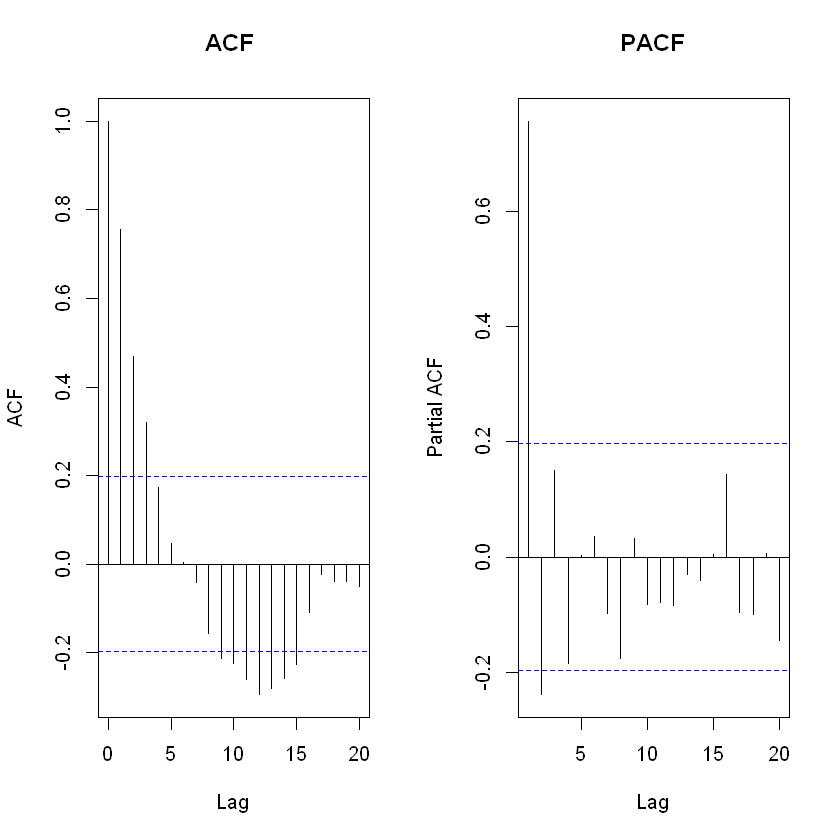

In [12]:
par(mfrow = c(1, 2))
acf(ts_data,  lag.max = 20, main = "ACF ")
pacf(ts_data, lag.max = 20, main = "PACF")

---
## 6. Ajuste do Modelo ARIMA

Podemos tanto **especificar manualmente** quanto usar o `auto.arima()` que testa automaticamente as combinações via critério de informação (AIC/BIC).

Com a saída do código abaixo, e pelo menor AIC, iremos ficar com o modelo ARIMA(1,0,1) que é um modelo ARMA(1,1)

```
Series: ts_data 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
         ar1     ma1    mean
      0.5269  0.5546  1.7374
s.e.  0.1098  0.1311  0.1274

sigma^2 = 0.158:  log likelihood = -48.22
AIC=104.43   AICc=104.86   BIC=114.81

Training set error measures:
                      ME      RMSE       MAE       MPE     MAPE      MASE
Training set 0.004466967 0.3914123 0.2898267 -10.81206 25.33637 0.9151758
                    ACF1
Training set -0.04648874

```

In [13]:
modelo_auto <- auto.arima(
  ts_data
)

cat("\n=== Modelo selecionado automaticamente ===\n")
summary(modelo_auto)


=== Modelo selecionado automaticamente ===


Series: ts_data 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
         ar1     ma1    mean
      0.5269  0.5546  1.7374
s.e.  0.1098  0.1311  0.1274

sigma^2 = 0.158:  log likelihood = -48.22
AIC=104.43   AICc=104.86   BIC=114.81

Training set error measures:
                      ME      RMSE       MAE       MPE     MAPE      MASE
Training set 0.004466967 0.3914123 0.2898267 -10.81206 25.33637 0.9151758
                    ACF1
Training set -0.04648874

---
## 7. Diagnóstico dos Resíduos

Tendo um modelo ajustado (ARIMA(1,0,1)) agora, podemos ver os resíduos.

Um bom modelo deve ter resíduos que se comportem como **ruído branco**:

- Média ≈ 0
- Variância constante (homocedasticidade)
- Sem autocorrelação significativa
- Distribuição aproximadamente normal

Um teste adequado nesse caso é o **Teste de Ljung-Box**: $H_0$ = não há autocorrelação nos resíduos.

Abaixo está um conjunto de gráfico feito com a função sarima do pacote astsa. E dá para ver que os resíduo comportam do jeito esperado:


- A média dos resíduos está em torno de zero

- Parecem homocedásticos e normais

- e o teste de Ljung-Box é feito para vário lags no último gráfico, isso nos diz que a hipótese de que os resíduos aleatórios e independentes não é rejeitada.

![Graficos feito com pacote astsa](7_residuos.png)


initial  value -0.451191 
iter   2 value -0.816312
iter   3 value -0.918728
iter   4 value -0.929643
iter   5 value -0.932677
iter   6 value -0.934289
iter   7 value -0.934414
iter   8 value -0.934419
iter   9 value -0.934421
iter  10 value -0.934423
iter  11 value -0.934424
iter  12 value -0.934424
iter  12 value -0.934424
iter  12 value -0.934424
final  value -0.934424 
converged
initial  value -0.931355 
iter   2 value -0.931638
iter   3 value -0.931812
iter   4 value -0.931905
iter   5 value -0.931906
iter   6 value -0.931906
iter   7 value -0.931906
iter   7 value -0.931906
iter   7 value -0.931906
final  value -0.931906 
converged
<><><><><><><><><><><><><><>
 
Coefficients: 
      Estimate     SE t.value p.value
ar1     0.5269 0.1098  4.7983   0e+00
ma1     0.5546 0.1311  4.2307   1e-04
xmean   1.7374 0.1274 13.6335   0e+00

sigma^2 estimated as 0.1532036 on 96 degrees of freedom 
 
AIC = 1.054874  AICc = 1.057426  BIC = 1.159727 
 


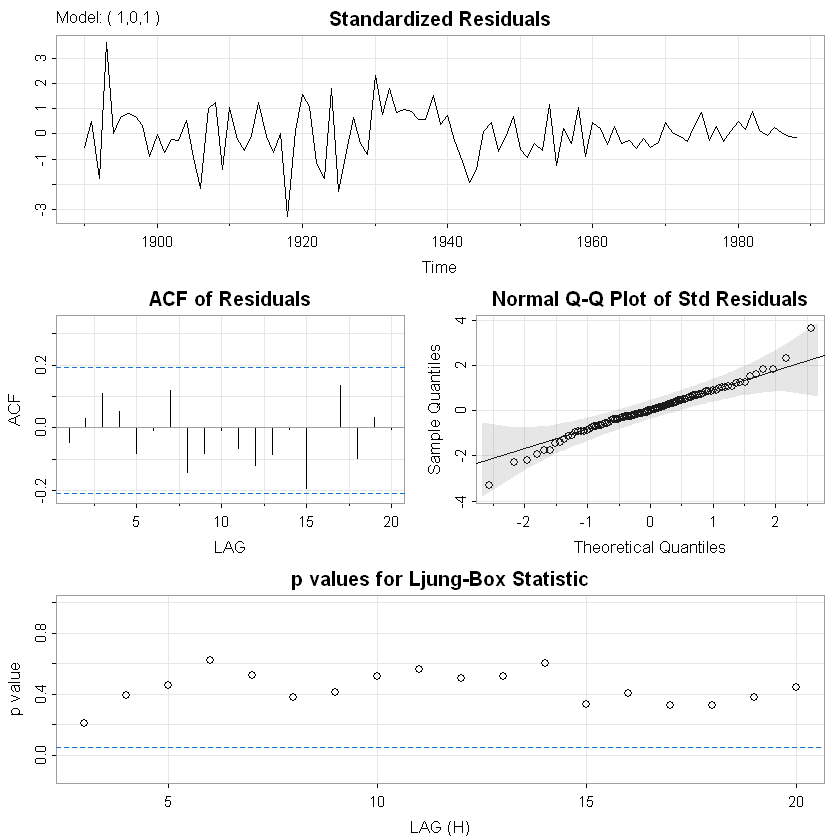

In [14]:
sarima(ts_data,1,0,1)

---
## 8. Previsão (*Forecast*)

O nosso modelo é validado, iremos gerar previsões (foco de horizonte = h = 5).

```

Point Forecast     Lo 80    Hi 80     Lo 95    Hi 95
1989       1.687894 1.1785011 2.197286 0.9088450 2.466942
1990       1.711332 0.9610145 2.461650 0.5638202 2.858845
1991       1.723682 0.9191736 2.528191 0.4932923 2.954072
1992       1.730190 0.9112718 2.549107 0.4777630 2.982616
1993       1.733618 0.9107450 2.556491 0.4751422 2.992094

```

O gráfico abaixo mostra uma visualização melhor das previsões (dentro do intervalo azul).

     Point Forecast     Lo 80    Hi 80     Lo 95    Hi 95
1989       1.687894 1.1785011 2.197286 0.9088450 2.466942
1990       1.711332 0.9610145 2.461650 0.5638202 2.858845
1991       1.723682 0.9191736 2.528191 0.4932923 2.954072
1992       1.730190 0.9112718 2.549107 0.4777630 2.982616
1993       1.733618 0.9107450 2.556491 0.4751422 2.992094

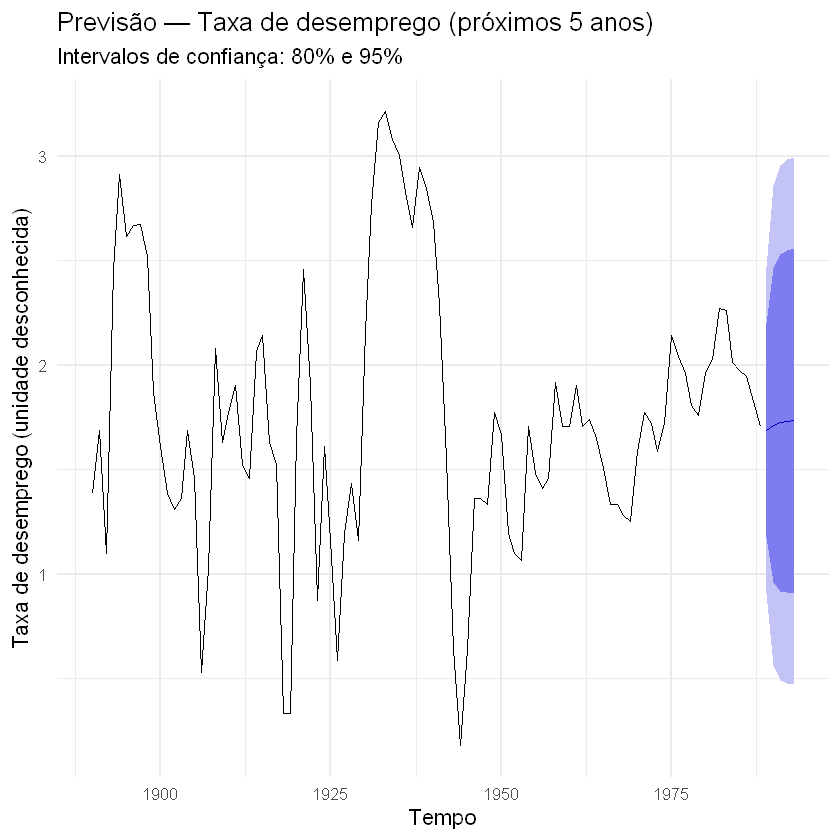

In [15]:
h <- 5  # horizonte de previsão

previsao <- forecast(modelo_auto, h = h, level = c(80, 95))
previsao
# Revertendo a transformação logarítmica
previsao_orig <- previsao
previsao_orig$mean  <- (previsao$mean)
previsao_orig$lower <- (previsao$lower)
previsao_orig$upper <- (previsao$upper)
previsao_orig$x     <- (previsao$x)

# Plot
autoplot(previsao_orig) +
  labs(
    title    = "Previsão — Taxa de desemprego (próximos 5 anos)",
    subtitle = "Intervalos de confiança: 80% e 95%",
    x        = "Tempo",
    y        = "Taxa de desemprego (unidade desconhecida)"
  ) +
  theme_minimal(base_size = 13)

---

### Série 2

Usaremos a série `MSFT` — preço das ações da empresa Microsoft de 2020 a 2026.

In [16]:
msft_data <- getSymbols("MSFT", 
                        src = "yahoo", 
                        from = "2020-01-01", 
                        to = "2026-05-29", 
                        auto.assign = FALSE)

preco <- msft_data[, "MSFT.Adjusted"]
preco <- as.numeric(preco)
ts_msft <- ts(preco, frequency = 252)

datas <- index(msft_data)
df_orig <- data.frame(
  data  = as.Date(datas),
  preco = preco
)

---
## 1. Carregamento e visualização inicial

Os dados são obtidos diretamente do Yahoo Finance via pacote `quantmod`. A coluna `MSFT.Adjusted` contém o **preço ajustado de fechamento**, que desconta dividendos e splits — é a mais adequada para análise de série temporal.

### Sobre a frequência

Dados de ações são **diários** (e não tem dados nos fins de semana: sábado e domingo), com aproximadamente 252 pregões por ano. A escolha de `frequency` afeta apenas a decomposição e a detecção de sazonalidade:

Usaremos **`frequency = 252`** para permitir a decomposição com perspectiva anual. Para a modelagem ARIMA, o valor de `frequency` não influencia o resultado — o que importa é a estrutura de dependência temporal.

**Olhar pros dados**.

![grafico da serie original](serie2_1_Serie.png)
![grafico da serie original](serie2_1_Serie_e_ma.png)


Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."


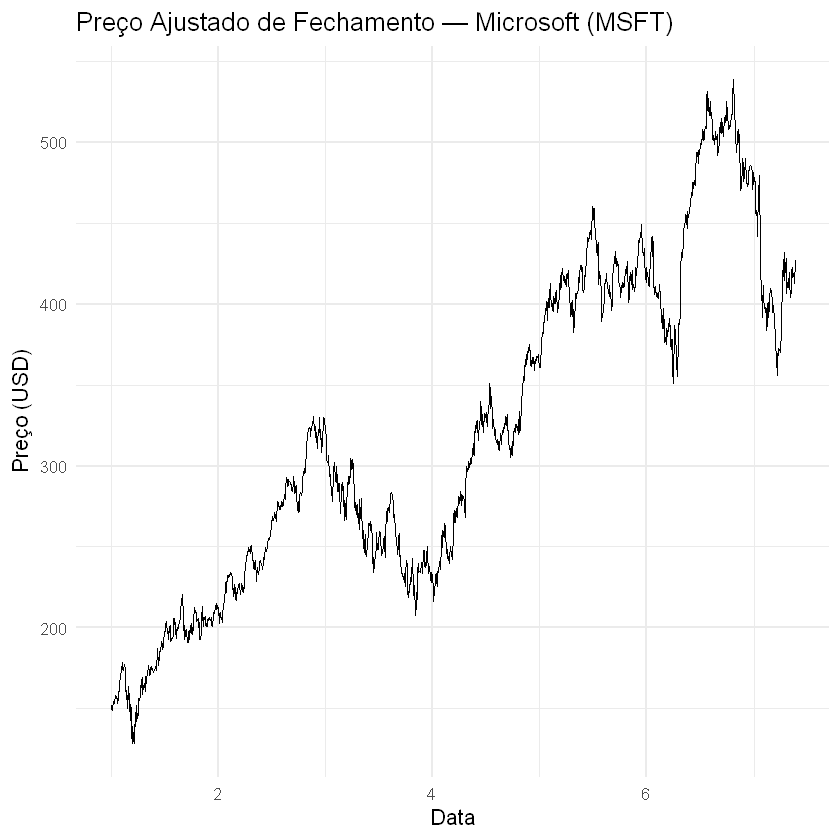

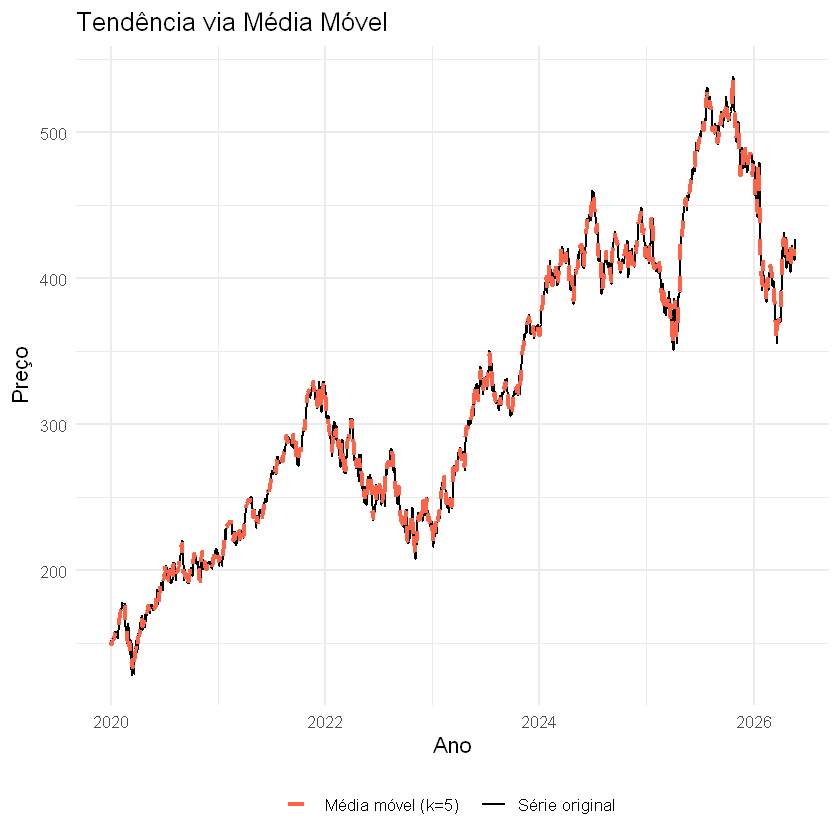

In [17]:
autoplot(ts_msft) +
  labs(
    title = "Preço Ajustado de Fechamento — Microsoft (MSFT)",
    x     = "Data",
    y     = "Preço (USD)"
  ) +
  theme_minimal(base_size = 13)

# Visualização de média móvel
tendencia <- rollmean(ts_msft, k = 2, fill = NA)

df_plot <- data.frame(
  ano       = as.numeric(time(ts_msft) + 2019),
  original  = as.numeric(ts_msft),
  tendencia = as.numeric(tendencia)
)

ggplot(df_plot, aes(x = ano)) +
  geom_line(aes(y = original,  color = "Série original"), linewidth = 0.8) +
  geom_line(aes(y = tendencia, color = "Média móvel (k=5)"), linewidth = 1.2, linetype = "dashed") +
  scale_color_manual(values = c("Série original" = "black", "Média móvel (k=5)" = "tomato")) +
  labs(title = "Tendência via Média Móvel", x = "Ano", y = "Preço", color = NULL) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "bottom")

**Observações da visualização:**

- Há uma **tendência crescente** ao longo do período, com forte aceleração entre 2020 e 2021, e novamente a partir de 2023.
- A **variância não é constante**: a amplitude das oscilações cresce junto com o nível da série — comportamento típico de série **heterocedástica**, sugerindo que uma **transformação logarítmica** pode ser útil.
- Não há evidências visuais claras de **sazonalidade**, pois não se observa um padrão regular e repetitivo de ciclos ao longo do período.
- Observa-se uma queda acentuada em 2022, possivelmente relacionada ao ciclo de alta de juros nos EUA.
- Visualmente, a série **não é estacionária** — tendência clara e variância crescente.
- O gráfico de média móvel tende a suavizar as oscilações de curto prazo e reforça a percepção da tendência crescente observada na série original.

---
## 2. Decomposição da série

Com `frequency = 252`, vamos usar a decomposição STL (que usa modelo de regressão LOESS para decompor) para tentar isolar um padrão sazonal anual.

Para séries de preços de ações, esse componente sazonal tende a ser **fraco** — o que reforça que o grosso da variação está na tendência e no resíduo.


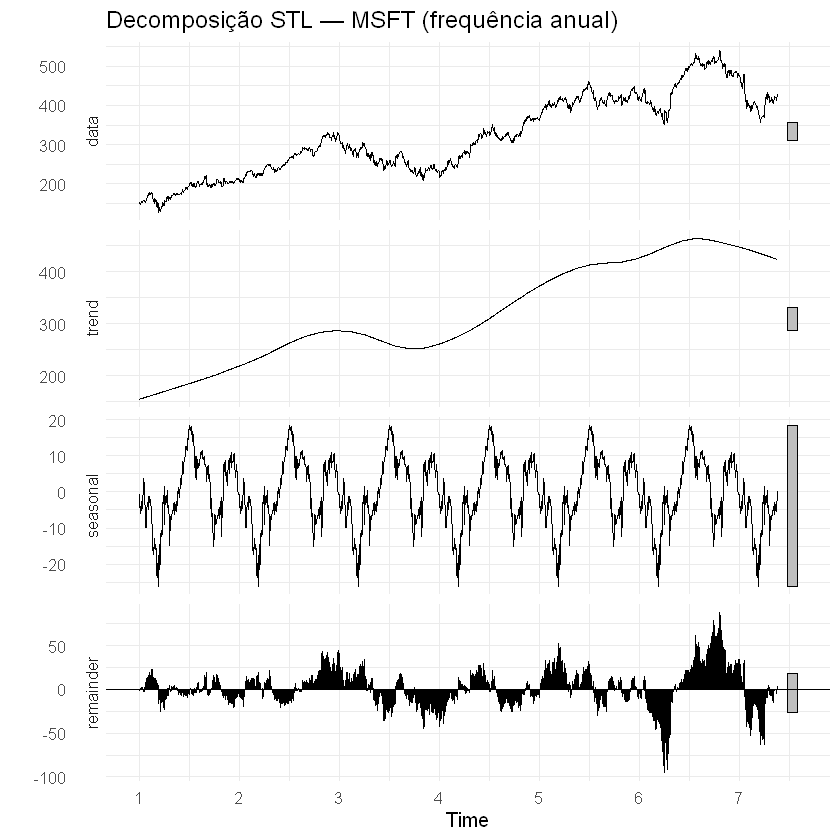

In [18]:
# STL requer frequency >= 2; com 252 funciona bem
stl_msft <- stl(ts_msft, s.window = "periodic", robust = TRUE)

autoplot(stl_msft) +
  labs(title = "Decomposição STL — MSFT (frequência anual)") +
  theme_minimal(base_size = 12)

---
## 3. Teste de Estacionariedade

- **ADF**: $H_0$ = tem raiz unitária (não estacionária). $p < 0{,}05$ → estacionária.

Usando a função "adf.test" do R temos um valor-p de 0.4198. Assim não rejeitamos a hipótese de que a série tem tendência ao nível de 5%.

```
	Augmented Dickey-Fuller Test

data:  ts_msft
Dickey-Fuller = -2.3745, Lag order = 11, p-value = 0.4198
alternative hypothesis: stationary

```

In [19]:
print(adf.test(ts_msft))


	Augmented Dickey-Fuller Test

data:  ts_msft
Dickey-Fuller = -2.3745, Lag order = 11, p-value = 0.4198
alternative hypothesis: stationary



---
## 4. Transformações para Estacionarizar

Para séries financeiras com variância crescente, podemos fazer o seguinte:

1. **Transformação log** — estabiliza a variância (converte a série em *log-preços*)
2. **Diferenciação simples** — remove a tendência, convertendo log-preços em **log-retornos**

O log-retorno $r_t = \log(P_t) - \log(P_{t-1})$ é a métrica padrão em finanças para analisar variações percentuais de preço.

```
Diferenças simples sugeridas (ndiffs)  : 1 
Diferenças sazonais sugeridas (nsdiffs): 0 
```

![grafico da serie transformada](serie2_4_serie_transformada.png)

ADF na série transformada: 

```
Warning message in adf.test(ts_logret):
"p-value smaller than printed p-value"

	Augmented Dickey-Fuller Test

data:  ts_logret
Dickey-Fuller = -11.655, Lag order = 11, p-value = 0.01
alternative hypothesis: stationary
```

Feito uma transformação de log-retorno, o teste aplicado na série transformada deu um valor-p menor que 0.01, que evidencia que a série está estabilizada.

Diferenças simples sugeridas (ndiffs)  : 1 
Diferenças sazonais sugeridas (nsdiffs): 0 


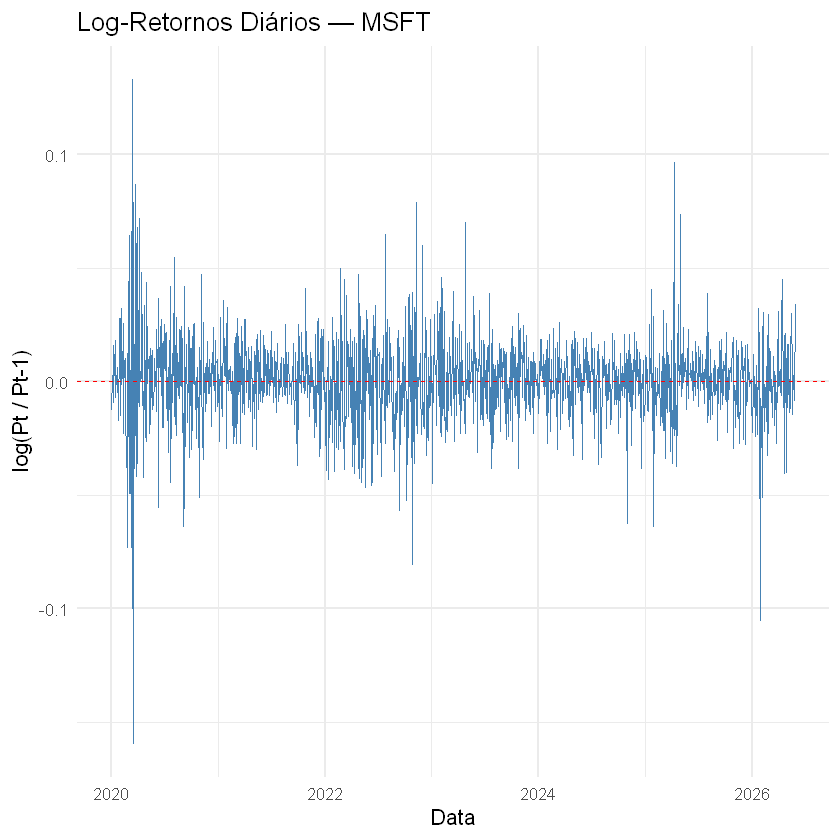

In [20]:
# Log-preços
ts_log <- log(ts_msft)

cat("Diferenças simples sugeridas (ndiffs)  :", ndiffs(ts_log), "\n")
cat("Diferenças sazonais sugeridas (nsdiffs):", nsdiffs(ts_log), "\n")

# Log-retornos = diff(log(preço))
ts_logret <- diff(ts_log)

# Visualização com datas
df_ret <- data.frame(
  data    = as.Date(datas[-1]),   # -1 pois diff reduz 1 obs
  logret  = as.numeric(ts_logret)
)

ggplot(df_ret, aes(x = data, y = logret)) +
  geom_line(color = "steelblue", linewidth = 0.4) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  labs(
    title = "Log-Retornos Diários — MSFT",
    x     = "Data",
    y     = "log(Pt / Pt-1)"
  ) +
  theme_minimal(base_size = 13)

In [21]:
print(adf.test(ts_logret))

Warning message in adf.test(ts_logret):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  ts_logret
Dickey-Fuller = -11.655, Lag order = 11, p-value = 0.01
alternative hypothesis: stationary



Feito uma transformação de log-retorno, o teste aplicado na série transformada deu um valor-p menor que 0.01, que evidencia que a série está estabilizada.

---
## 5. Identificação do Modelo — ACF e PACF

Analisamos os gráficos de ACF e PACF dos **log-retornos** (série estacionária) para identificar as ordens $p$ e $q$.

Para séries financeiras, é muito comum que os log-retornos se comportem como **ruído branco** — sem autocorrelação linear significativa. Isso levaria a um ARIMA(0,1,0) nos log-preços (equivalente a um *random walk*), que é o modelo de precificação eficiente de mercado de acordo com informações da internet.


![ACF e PACF da serie transformada](serie2_5_grafico_ACF_e_PACF.png)

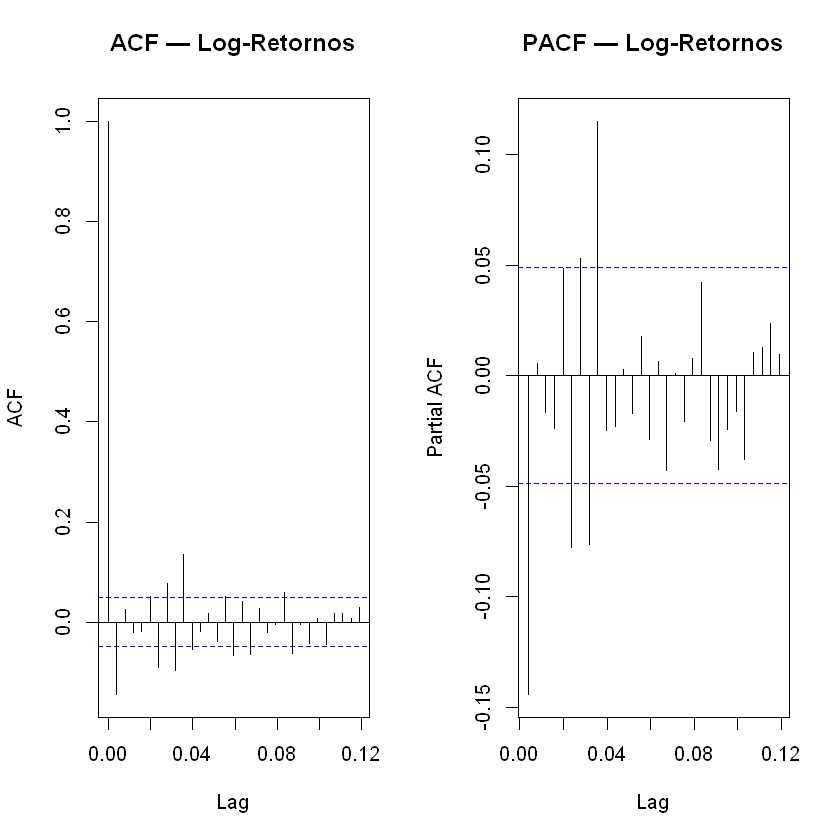

In [22]:
par(mfrow = c(1, 2))
acf(ts_logret,  lag.max = 30, main = "ACF — Log-Retornos")
pacf(ts_logret, lag.max = 30, main = "PACF — Log-Retornos")

**Observações da visualização:**

- A ACF dos log-retornos apresenta autocorrelações muito próximas de zero (nenhuma passou de 0.2, embora tenha algumas passou da linha azul tracejada que R calculou) na maior parte das defasagens, indicando baixa dependência linear entre observações consecutivas.

- Apenas alguns lags isolados ultrapassam os limites de significância, mas não formam um padrão persistente de autocorrelação.

- A PACF também mostra poucos coeficientes significativos, sem um comportamento de corte claro que sugira um modelo AR(p) específico.

- A ausência de um padrão sistemático na ACF e na PACF sugere que os log-retornos podem ser aproximados por um processo de ruído branco em termos da média.

- Não há evidências visuais fortes que justifiquem a inclusão de componentes autorregressivos ou de médias móveis de ordem elevada.

- Tudo isso pode indicar que modelo talvez seja um ARIMA(0,1,0), ou seja um ruído branco. Entretanto isso parece ser comum nas séries financeiras já que o log-retorno se comporta assim e tem casos onde pessoas usam passeio aleatório para modelar.

Enfim o próximo passo iremos ver se a função auto.arima do R nos diz outra coisa.

---
## 6. Ajuste do Modelo ARIMA

Rodamos o `auto.arima()` na série de **log-preços** (não nos log-retornos). Isso porque o `auto.arima()` determina internamente o $d$, e queremos que o modelo final seja expresso como ARIMA$(p, d, q)$ na escala dos log-preços para facilitar a previsão.

Saída do R:
```
Series: ts_log 
ARIMA(1,1,0) with drift 

Coefficients:
          ar1  drift
      -0.1445  6e-04
s.e.   0.0247  4e-04

sigma^2 = 0.0003431:  log likelihood = 4133.35
AIC=-8260.71   AICc=-8260.69   BIC=-8244.56

Training set error measures:
                        ME       RMSE        MAE           MPE      MAPE
Training set -5.464763e-07 0.01850476 0.01300782 -0.0002249733 0.2315614
                   MASE         ACF1
Training set 0.05616332 0.0006359383

```

In [23]:
# auto.arima aplicado nos LOG-PREÇOS (série original transformada)
modelo_auto_ms <- auto.arima(
  ts_log,
)

cat("\n=== Modelo selecionado automaticamente ===\n")
summary(modelo_auto_ms)


=== Modelo selecionado automaticamente ===


Series: ts_log 
ARIMA(0,1,0)(1,0,0)[252] with drift 

Coefficients:
         sar1  drift
      -0.0212  6e-04
s.e.   0.0296  5e-04

sigma^2 = 0.0003502:  log likelihood = 4116.68
AIC=-8227.36   AICc=-8227.35   BIC=-8211.21

Training set error measures:
                      ME      RMSE      MAE           MPE      MAPE       MASE
Training set 8.00835e-06 0.0186971 0.012979 -7.684943e-05 0.2312965 0.05603888
                   ACF1
Training set -0.1441781

A função auto.arima diz que o modelo selecionado é ARIMA(1,1,0) with drift.

O resumo do modelo está abaixo:

```

Series: ts_log 
ARIMA(1,1,0) with drift 

Coefficients:
          ar1  drift
      -0.1445  6e-04
s.e.   0.0247  4e-04

sigma^2 = 0.0003431:  log likelihood = 4133.36
AIC=-8260.71   AICc=-8260.7   BIC=-8244.56

Training set error measures:
                        ME       RMSE        MAE          MPE      MAPE
Training set -5.465093e-07 0.01850475 0.01300781 -0.000224974 0.2315613
                   MASE         ACF1
Training set 0.05616329 0.0006359506

```

---
## 7. Diagnóstico dos Resíduos

Tendo um modelo ajustado ARIMA(1,1,0).
Verificamos se os resíduos do modelo se comportam como **ruído branco**:


Abaixo está um conjunto de gráfico feito com a função sarima do pacote astsa. E dá para ver que os resíduo comportam assim:

- A média dos resíduos está em torno de zero

- A normalidade não é muito bem atendida pelo QQ-plot por ter caudas pesadas, tem pontos que desviaram da reta. Poderia fazer um teste de normalidade (exemplo: Shapiro-Wilk), mas sabemos que o modelo é robusto a desvio da normalidade. 

- O gráfico de resíduos apresenta uma estrutura diferente no final, pode ser que isso indique que a homocedasticidade é levemente violada.

- e o teste de Ljung-Box é feito para vário lags no último gráfico, isso nos diz que a hipótese de que os resíduos aleatórios e independentes não é rejeitada.

![gráfico do diagnostico](serie2_7_diagnostico.png)


initial  value 1.684146 
iter   2 value 1.683200
iter   2 value 1.683200
iter   2 value 1.683200
final  value 1.683200 
converged
initial  value 1.682935 
iter   1 value 1.682935
final  value 1.682935 
converged
<><><><><><><><><><><><><><>
 
Coefficients: 
         Estimate     SE t.value p.value
ar1       -0.0435 0.0250 -1.7441  0.0813
constant   0.1712 0.1286  1.3314  0.1832

sigma^2 estimated as 28.95866 on 1606 degrees of freedom 
 
AIC = 6.207479  AICc = 6.207484  BIC = 6.217521 
 


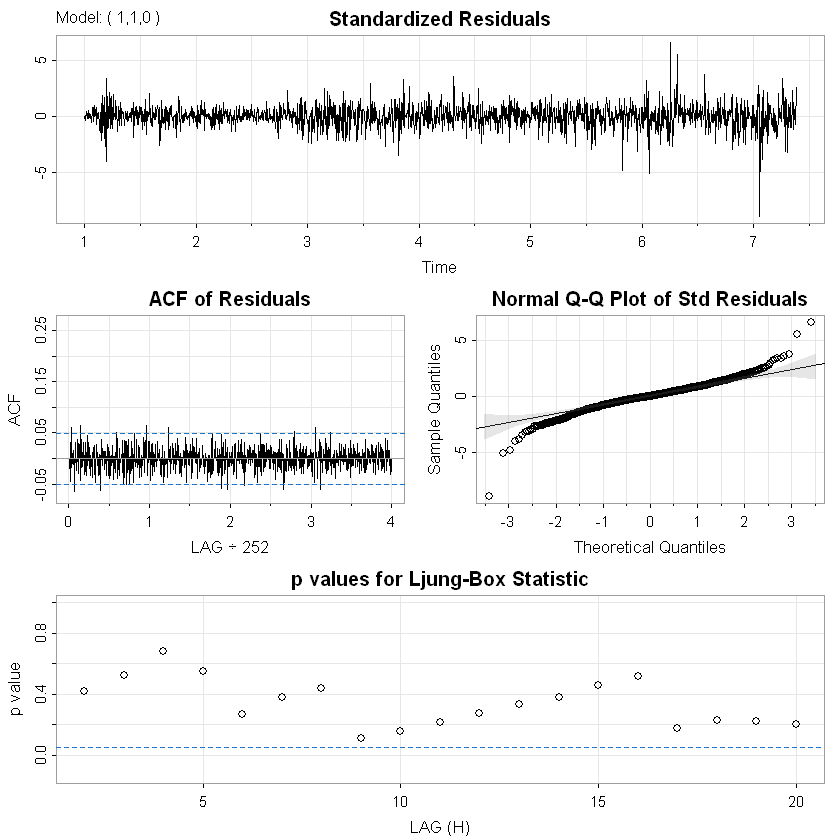

In [24]:
sarima(ts_msft,1,1,0)

---
## 8. Previsão

Geramos previsões para os próximos **30 pregões** (~6 semanas) na escala de log-preços e revertemos com `exp()` para a escala original de preço em USD.

O gráfico abaixo mostra uma visualização melhor das previsões (dentro do intervalo azul).

![alt text](serie2_8_previsao.png)

         Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
7.384921       427.3352 417.2081 437.7082 411.9446 443.3008
7.388889       427.5890 413.3293 442.3408 405.9741 450.3548
7.392857       427.8360 410.4274 445.9830 401.5004 455.8990
7.396825       428.0846 408.0352 449.1191 397.8047 460.6694
7.400794       428.3454 405.9787 451.9443 394.6152 464.9587
7.404762       428.6083 404.1539 454.5424 391.7785 468.9004
7.408730       428.8148 402.4498 456.9071 389.1557 472.5157
7.412698       429.0434 400.9040 459.1579 386.7629 475.9460
7.416667       429.2788 399.4768 461.3042 384.5474 479.2135
7.420635       429.5952 398.2183 463.4444 382.5470 482.4297
7.424603       429.8438 396.9765 465.4323 380.6075 485.4495
7.428571       430.0058 395.7239 467.2575 378.6968 488.2666
7.432540       430.3621 394.7105 469.2339 377.0492 491.2131
7.436508       430.5641 393.6088 470.9891 375.3477 493.9033
7.440476       430.8671 392.6471 472.8074 373.8068 496.6374
7.444444       431.1074 391.6711 474.514

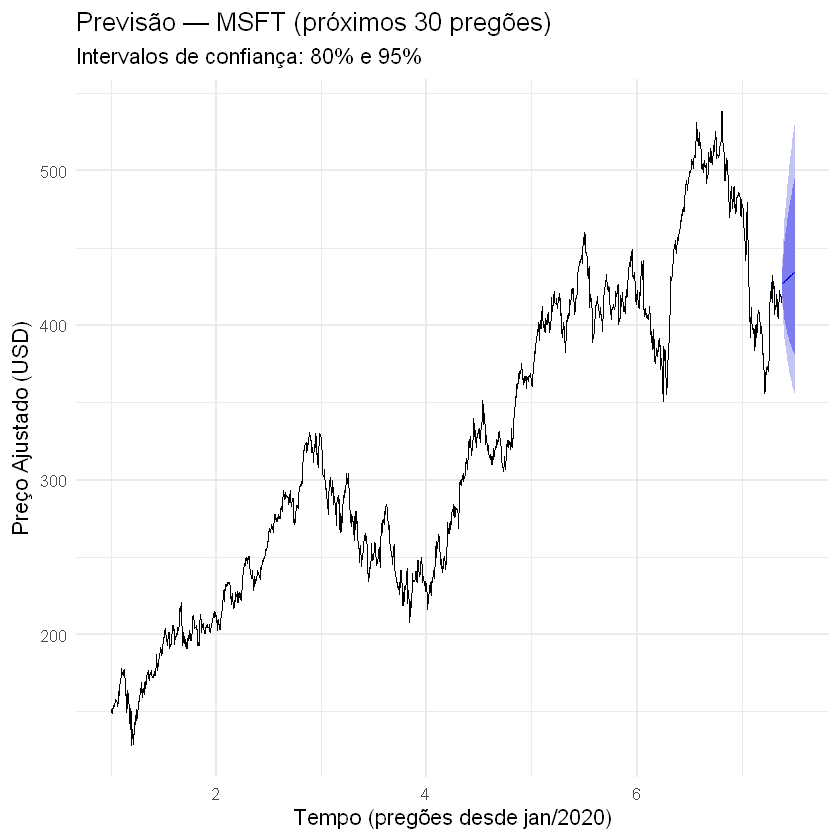

In [27]:
h <- 30  # 30 pregões à frente

prev_log <- forecast(modelo_auto_ms, h = h, level = c(80, 95))

# Revertendo a transformação log → escala original
prev_orig        <- prev_log
prev_orig$mean   <- exp(prev_log$mean)
prev_orig$lower  <- exp(prev_log$lower)
prev_orig$upper  <- exp(prev_log$upper)
prev_orig$x      <- exp(prev_log$x)

prev_orig

autoplot(prev_orig) +
  labs(
    title    = "Previsão — MSFT (próximos 30 pregões)",
    subtitle = "Intervalos de confiança: 80% e 95%",
    x        = "Tempo (pregões desde jan/2020)",
    y        = "Preço Ajustado (USD)"
  ) +
  theme_minimal(base_size = 13)